# **UM-BMID: 2D Microwave Image Reconstruction & Tumor Localization Pipeline**

### Dataset: UM-BMID Generation 2 Microwave Radar Scans (`gen_two`)
### Companion notebook to the tumor classification (1D/2D-CNN) notebook — same `DATA_DIR`, same phantom subset.

This notebook implements a from-scratch 2D image reconstruction and spatial localization
pipeline: DAS / DMAS / MER / TSVD reconstruction, binary mask + centroid extraction,
a closed-loop centroid-alignment demo, and a 4-metric evaluation scorecard (CLE, Dice, SCR, runtime).


## 1. Setup, Data Loading & Engineering Assumptions

The raw `.pickle` files only contain S-parameters and metadata — they do **not** contain
the frequency sweep, the tissue permittivity, or the antenna's angular layout. Those are
physical facts about the UM-BMID Gen-2 acquisition system, not free parameters, so they're
pinned here as named constants (not silently hard-coded inline) so they're easy to check
or correct against the dataset documentation if you have it:

- **Frequency sweep**: 1–9 GHz, 1001 points (standard UM-BMID Gen-2 VNA sweep).
- **Antenna ring**: 72 synthetic monostatic/bistatic positions on a circle of radius `ant_rad`
  (from metadata, ~21 cm), at height `ant_z`.
- **Effective propagation speed**: through the glycerin/oil immersion medium, assumed
  relative permittivity ≈ 9 (typical matching-medium value used in UM-BMID literature).
  This directly scales every time-of-flight delay, so if your calibration differs, change
  `AVG_PERMITTIVITY` below — everything downstream depends on it.
- **Imaging plane**: a single 2D (x, y) slice at the antenna height `ant_z`, i.e. `tum_z` is
  used only for sample *stratification* (shallow vs. deep), not for the 2D reconstruction
  itself. A true depth-resolved reconstruction would need a 3D grid; out of scope here.


In [2]:
import os
import re
import time
import pickle
import itertools
import numpy as np
from scipy.sparse.linalg import cg, LinearOperator

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import hilbert

np.random.seed(42)

# --- Physical / acquisition constants (documented assumptions, see markdown above) ---
FREQ_START_HZ      = 1e9
FREQ_STOP_HZ       = 9e9
N_FREQ             = 1001
N_ANTENNAS         = 72
AVG_PERMITTIVITY   = 9.0          # matching-medium relative permittivity
C0                 = 3e8          # speed of light, m/s
V_EFF              = C0 / np.sqrt(AVG_PERMITTIVITY)

GRID_SIZE          = 256          # pixel grid is GRID_SIZE x GRID_SIZE
THRESH_RATIO       = 0.15         # top 15% intensity -> binary mask
CONVERGENCE_TOL    = 0.01         # pixels, for the Stage 4 alignment loop


In [3]:
# --- 2. Load data (same subset as the classification notebook) ---
#from google.colab import drive
#drive.mount('/content/drive')

DATA_DIR  = r'D:\UM-BMID DATASET'
S11_FILE  = r'D:\UM-BMID DATASET\fd_data_gen_two_s11.pickle'
S21_FILE  = r'D:\UM-BMID DATASET\fd_data_gen_two_s21.pickle'
META_FILE = r'D:\UM-BMID DATASET\metadata_gen_two.pickle'

with open(os.path.join(DATA_DIR, S11_FILE), 'rb') as f:
    s11_raw = pickle.load(f)

with open(os.path.join(DATA_DIR, S21_FILE), 'rb') as f:
    s21_raw = pickle.load(f)

with open(os.path.join(DATA_DIR, META_FILE), 'rb') as f:
    metadata_raw = pickle.load(f)

print("S11 shape:", s11_raw.shape)   # (N_scans, N_freqs, N_antennas)
print("S21 shape:", s21_raw.shape)
df_meta = pd.DataFrame(metadata_raw)
print("Metadata shape:", df_meta.shape)


S11 shape: (1301, 1001, 72)
S21 shape: (1301, 1001, 72)
Metadata shape: (1301, 22)


In [4]:
# --- 3. Ground-truth tumor labels + density-class parsing ---
# tum_x / tum_y / tum_z / tum_rad / tum_shape are NaN for healthy (no-tumor) scans,
# so localization ground truth only exists where a tumor is actually present.
df_meta['has_tumor'] = df_meta['tum_rad'].notna()

# phant_id follows the UM-BMID convention "A<shell_class><shell_id>F<fib_id>",
# e.g. 'A11F14' -> adipose shell class 1 (low density), shell id 1, fibroglandular id 14.
# Shell class 1/2/3 roughly correspond to low/medium/high breast density.
def parse_density_class(phant_id):
    m = re.match(r'A(\d)', str(phant_id))
    return int(m.group(1)) if m else np.nan

df_meta['density_class'] = df_meta['phant_id'].apply(parse_density_class)

print(df_meta['density_class'].value_counts(dropna=False))
print(f"Tumor-positive scans available for localization: {df_meta['has_tumor'].sum()} / {len(df_meta)}")


density_class
1.0    895
NaN    152
2.0    127
3.0    127
Name: count, dtype: int64
Tumor-positive scans available for localization: 504 / 1301


## 2. Stratified Batch Selection (Rule 2)

Seed is locked at 42. All five picks are restricted to `has_tumor == True` rows, since
there is no localization ground truth for healthy scans. Depth (shallow/deep) is read
from `tum_z`, density class from the `phant_id`-derived `density_class` (1 = low, 3 = high),
and clutter level is approximated as high whenever `density_class == 3` (denser
fibroglandular content scatters more).


In [5]:
def pick_stratified_batch(df, seed=42):
    rng = np.random.RandomState(seed)
    tumor_df = df[df['has_tumor']].copy()

    picks = {}

    # 1. Shallow depth / low density
    cand = tumor_df[tumor_df['density_class'] == 1].sort_values('tum_z', ascending=False)
    picks['shallow_low_density'] = cand.index[0]

    # 2. Deep depth / low density
    cand = tumor_df[tumor_df['density_class'] == 1].sort_values('tum_z', ascending=True)
    picks['deep_low_density'] = cand.index[0]

    # 3. Mid depth / high density (high clutter, low contrast)
    cand = tumor_df[tumor_df['density_class'] == 3].copy()
    cand['depth_centrality'] = (cand['tum_z'] - cand['tum_z'].median()).abs()
    cand = cand.sort_values('depth_centrality', ascending=True)
    picks['mid_high_density'] = cand.index[0]

    # 4. Smallest tumor radius (weak spatial signature)
    picks['small_tumor'] = tumor_df.sort_values('tum_rad', ascending=True).index[0]

    # 5. Largest tumor radius (strong spatial signature)
    picks['large_tumor'] = tumor_df.sort_values('tum_rad', ascending=False).index[0]

    return picks

batch_picks = pick_stratified_batch(df_meta, seed=42)
batch_df = df_meta.loc[list(batch_picks.values()),
                       ['id', 'phant_id', 'density_class', 'tum_z', 'tum_rad', 'tum_x', 'tum_y']].copy()
batch_df.index = list(batch_picks.keys())
print(batch_df)

SAMPLE_INDICES = list(batch_picks.values())   # row indices into s11_raw / s21_raw / df_meta
SAMPLE_LABELS  = list(batch_picks.keys())


                       id phant_id  density_class  tum_z  tum_rad  tum_x  \
shallow_low_density   816     A1F1            1.0   -3.0      0.5  -0.75   
deep_low_density      176   A11F11            1.0   -6.7      1.0  -0.75   
mid_high_density      629    A3F12            3.0   -6.7      1.0  -2.25   
small_tumor          1250    A3F11            3.0   -6.7      0.5   2.25   
large_tumor          1268     A3F4            3.0   -6.5      1.5  -2.25   

                     tum_y  
shallow_low_density   3.00  
deep_low_density     -3.75  
mid_high_density     -3.75  
small_tumor           2.25  
large_tumor          -3.75  


## 3. Stage 1 — Signal Conditioning & Calibration

1. IFFT the frequency-domain S-parameters to a (pseudo) time domain.
2. Remove the dominant skin reflection with average-subtraction calibration
   (subtract the cross-channel mean at each time sample).
3. Take the analytic-signal magnitude via the Hilbert transform for a smooth envelope.


In [6]:
def ifft_time_domain(raw_scan):
    """raw_scan: (N_freq, N_antennas) complex -> (N_freq, N_antennas) time-domain magnitude-ready signal."""
    return np.fft.ifft(raw_scan, axis=0)

def average_subtraction_calibration(td_scan):
    """td_scan: (N_time, N_antennas). Subtract the cross-channel mean at each time sample."""
    channel_mean = np.mean(td_scan, axis=1, keepdims=True)
    return td_scan - channel_mean

def hilbert_envelope(calibrated_scan):
    """Analytic-signal envelope, magnitude only, per channel."""
    analytic = hilbert(np.real(calibrated_scan), axis=0)
    return np.abs(analytic)

# Time axis for the (pseudo) time-domain signal, derived from the swept bandwidth.
BANDWIDTH_HZ = FREQ_STOP_HZ - FREQ_START_HZ
TIME_AXIS = np.arange(N_FREQ) / BANDWIDTH_HZ   # seconds, index 0..N_FREQ-1

sample_signals = {}
for label, idx in zip(SAMPLE_LABELS, SAMPLE_INDICES):
    td_s11 = ifft_time_domain(s11_raw[idx])
    td_s21 = ifft_time_domain(s21_raw[idx])
    cal_s11 = average_subtraction_calibration(td_s11)
    cal_s21 = average_subtraction_calibration(td_s21)
    env_s11 = hilbert_envelope(cal_s11)
    env_s21 = hilbert_envelope(cal_s21)
    sample_signals[label] = {'s11': env_s11, 's21': env_s21}

print("Conditioned signal shape per sample:", sample_signals[SAMPLE_LABELS[0]]['s11'].shape)


Conditioned signal shape per sample: (1001, 72)


## 4. Stage 2 — Parallel 2D Image Reconstruction Engines

Antenna positions are placed on a circle of radius `ant_rad` (from metadata) at 72 evenly
spaced angles. The pixel grid spans `[-ant_rad, +ant_rad]` in both x and y (the full
antenna-ring diameter), mapped onto a 256x256 matrix. Delay-based methods (DAS, DMAS) use
`V_EFF` to convert distance to time-of-flight and interpolate into the conditioned time
signal.

`TSVD` here is a simplified linear Born-approximation inversion: a synthetic forward
sensitivity matrix `A` (free-space Green's-function-like kernel at the sweep's center
frequency) maps pixel reflectivity to per-antenna measurement magnitude; the tumor image
is recovered by truncated-SVD pseudo-inversion. This is a coursework-level approximation
of Born inversion, not a full electromagnetic forward solver.


In [7]:
def antenna_positions(ant_rad, n_antennas=N_ANTENNAS):
    angles = np.linspace(0, 2 * np.pi, n_antennas, endpoint=False)
    x = ant_rad * np.cos(angles)
    y = ant_rad * np.sin(angles)
    return np.stack([x, y], axis=1)   # (N_antennas, 2), cm

def pixel_grid(ant_rad, grid_size=GRID_SIZE):
    coords = np.linspace(-ant_rad, ant_rad, grid_size)
    xx, yy = np.meshgrid(coords, coords)
    return xx, yy, coords   # xx, yy: (grid_size, grid_size) in cm

def antenna_pixel_distances(ant_pos, xx, yy):
    """Returns (N_antennas, grid_size*grid_size) distances in cm."""
    px = xx.ravel()
    py = yy.ravel()
    dx = ant_pos[:, 0:1] - px[None, :]
    dy = ant_pos[:, 1:2] - py[None, :]
    return np.sqrt(dx ** 2 + dy ** 2)   # cm

def delay_to_sample_index(distances_cm, time_axis, v_eff=V_EFF, round_trip=True):
    """Convert antenna-to-pixel distance to a time-domain sample index (round-trip TOF)."""
    dist_m = distances_cm / 100.0
    factor = 2.0 if round_trip else 1.0
    tof = factor * dist_m / v_eff
    idx = np.searchsorted(time_axis, tof)
    return np.clip(idx, 0, len(time_axis) - 1)


In [8]:
def reconstruct_das(env_signal, ant_pos, xx, yy, time_axis):
    """Standard Delay-and-Sum. env_signal: (N_time, N_antennas)."""
    distances = antenna_pixel_distances(ant_pos, xx, yy)          # (N_ant, N_pix)
    sample_idx = delay_to_sample_index(distances, time_axis)      # (N_ant, N_pix)
    n_ant, n_pix = sample_idx.shape
    image = np.zeros(n_pix)
    for a in range(n_ant):
        image += env_signal[sample_idx[a], a]
    return image.reshape(xx.shape)


In [9]:
def reconstruct_dmas(env_signal, ant_pos, xx, yy, time_axis):
    """Delay-Multiply-and-Sum: pairwise sign(s_i*s_j) * sqrt(|s_i*s_j|), summed over all pairs i<j."""
    distances = antenna_pixel_distances(ant_pos, xx, yy)
    sample_idx = delay_to_sample_index(distances, time_axis)
    n_ant, n_pix = sample_idx.shape

    # Pre-gather each antenna's delayed signal value at every pixel: (N_ant, N_pix)
    aligned = np.stack([env_signal[sample_idx[a], a] for a in range(n_ant)], axis=0)

    image = np.zeros(n_pix)
    for i, j in itertools.combinations(range(n_ant), 2):
        prod = aligned[i] * aligned[j]
        image += np.sign(prod) * np.sqrt(np.abs(prod))
    return image.reshape(xx.shape)


In [10]:
def reconstruct_mer(env_signal, ant_pos, xx, yy, time_axis, eps=1e-12):
    """Microwave Entropy Reconstruction: per-pixel Shannon entropy across the aligned
    antenna channel vector, inverted so low entropy (coherent focus) -> high intensity."""
    distances = antenna_pixel_distances(ant_pos, xx, yy)
    sample_idx = delay_to_sample_index(distances, time_axis)
    n_ant, n_pix = sample_idx.shape

    aligned = np.stack([env_signal[sample_idx[a], a] for a in range(n_ant)], axis=0)  # (N_ant, N_pix)
    aligned = np.abs(aligned)
    channel_sum = aligned.sum(axis=0, keepdims=True) + eps
    p = aligned / channel_sum                                     # probability dist. per pixel
    entropy = -np.sum(p * np.log(p + eps), axis=0)                # (N_pix,)
    max_entropy = np.log(n_ant)
    image = max_entropy - entropy                                 # invert: low entropy -> high value
    return image.reshape(xx.shape)


In [11]:
def reconstruct_tsvd(env_signal, ant_pos, xx, yy, time_axis, k_singular=20):
    """Simplified linear (Born-approximation) inversion via truncated SVD.
    Forward model: measurement at antenna a ~ sum_pixels exp(-j*k0*r_a,pixel) / r_a,pixel * reflectivity(pixel).
    A representative per-antenna scalar measurement is taken as the peak envelope value.
    """
    freqs = np.linspace(FREQ_START_HZ, FREQ_STOP_HZ, N_FREQ)
    f_center = freqs[len(freqs) // 2]
    k0 = 2 * np.pi * f_center * np.sqrt(AVG_PERMITTIVITY) / C0

    distances_cm = antenna_pixel_distances(ant_pos, xx, yy)   # (N_ant, N_pix)
    r_m = np.clip(distances_cm / 100.0, 1e-3, None)
    A = np.exp(-1j * k0 * r_m) / r_m                          # (N_ant, N_pix) forward operator

    measurement = env_signal.max(axis=0)                      # (N_ant,) peak envelope per antenna

    U, S, Vt = np.linalg.svd(A, full_matrices=False)
    k = min(k_singular, len(S))
    S_trunc_inv = np.zeros_like(S)
    S_trunc_inv[:k] = 1.0 / S[:k]
    pseudo_inverse = (Vt.T * S_trunc_inv) @ U.T                 # (N_pix, N_ant)

    reflectivity = pseudo_inverse @ measurement.astype(complex)  # (N_pix,)
    image = np.abs(reflectivity)
    return image.reshape(xx.shape)


## 5. Run All Four Algorithms Across the 5-Sample Batch (with timing)

In [12]:
ALGORITHMS = {
    'DAS':  reconstruct_das,
    'DMAS': reconstruct_dmas,
    'MER':  reconstruct_mer,
    'TSVD': reconstruct_tsvd,
}

reconstructions = {}   # reconstructions[label][algo_name] = 2D image
runtimes = {}          # runtimes[label][algo_name] = seconds

for label, idx in zip(SAMPLE_LABELS, SAMPLE_INDICES):
    ant_rad = df_meta.loc[idx, 'ant_rad']
    xx, yy, coords = pixel_grid(ant_rad)
    ant_pos = antenna_positions(ant_rad)
    env_signal = sample_signals[label]['s11']   # (N_time, N_antennas), monostatic

    reconstructions[label] = {}
    runtimes[label] = {}
    for algo_name, algo_fn in ALGORITHMS.items():
        t0 = time.perf_counter()
        image = algo_fn(env_signal, ant_pos, xx, yy, TIME_AXIS)
        elapsed = time.perf_counter() - t0
        reconstructions[label][algo_name] = image
        runtimes[label][algo_name] = elapsed
        print(f"{label:22s} | {algo_name:5s} | {elapsed:6.3f}s")


shallow_low_density    | DAS   |  0.159s
shallow_low_density    | DMAS  |  0.656s
shallow_low_density    | MER   |  0.206s
shallow_low_density    | TSVD  |  2.479s
deep_low_density       | DAS   |  0.164s
deep_low_density       | DMAS  |  0.830s
deep_low_density       | MER   |  0.241s
deep_low_density       | TSVD  |  2.615s
mid_high_density       | DAS   |  0.152s
mid_high_density       | DMAS  |  0.763s
mid_high_density       | MER   |  0.242s
mid_high_density       | TSVD  |  2.352s
small_tumor            | DAS   |  0.124s
small_tumor            | DMAS  |  0.541s
small_tumor            | MER   |  0.184s
small_tumor            | TSVD  |  2.211s
large_tumor            | DAS   |  0.127s
large_tumor            | DMAS  |  0.545s
large_tumor            | MER   |  0.207s
large_tumor            | TSVD  |  2.297s


## 6. Stage 3 — Binary Thresholding & Centroid Extraction

Top `THRESH_RATIO` (15%) of intensity -> binary mask -> first-order spatial moments
(pixel-index centroid).


In [13]:
def threshold_mask_spatial(image, ant_rad, coords, thresh_ratio=THRESH_RATIO):
    """
    Cleans skin/antenna ring artifacts by zeroing out the outer edge of 
    the phantom before applying the top-15% intensity threshold.
    """
    # Create a 2D mesh grid of physical space (cm)
    xx, yy = np.meshgrid(coords, coords)
    distance_from_center = np.hypot(xx, yy)
    
    # Create a copy of the image to process safely
    cleaned_image = image.copy()
    
    # STRATEGY: Zero out everything within 20% of the antenna ring boundary
    # This strips away the persistent yellow ring artifact completely!
    cleaned_image[distance_from_center >= (ant_rad * 0.8)] = 0.0
    
    # Now execute your original min/max cutoff logic on the clean interior tissue zone
    lo, hi = cleaned_image.min(), cleaned_image.max()
    cutoff = hi - thresh_ratio * (hi - lo)
    mask = (cleaned_image >= cutoff).astype(int)
    return mask

def mask_centroid(mask):
    ys, xs = np.nonzero(mask)
    if len(xs) == 0:
        return np.nan, np.nan
    return xs.mean(), ys.mean()   # (col, row) = (x_pixel, y_pixel)

masks = {}
centroids_px = {}

for label in SAMPLE_LABELS:
    # Look up the physical properties for this specific sample row
    idx = df_meta[df_meta['has_tumor']].index[SAMPLE_LABELS.index(label)]
    ant_rad = df_meta.loc[idx, 'ant_rad']
    _, _, coords = pixel_grid(ant_rad) # Extract spatial coordinate vector
    
    masks[label] = {}
    centroids_px[label] = {}
    for algo_name in ALGORITHMS:
        # Pass the spatial boundaries to clean up DAS/DMAS/MER rings!
        m = threshold_mask_spatial(reconstructions[label][algo_name], ant_rad, coords)
        masks[label][algo_name] = m
        centroids_px[label][algo_name] = mask_centroid(m)

## 7. Stage 4 — Closed-Loop Vector Distance Minimization (registration demo)

**Important scope note:** this stage forcibly translates the mask pixels toward the
known ground-truth coordinate until the residual distance is below tolerance. That makes
it a *visual registration/alignment demo* — useful for showing "if the algorithm's blob
were correctly registered, here's the tumor shape it recovered" — not a scoring step.

If this loop ran *before* the scorecard in Section 8, every algorithm's Centroid
Localization Error would trivially converge to ~0, which would defeat the whole purpose
of measuring localization accuracy. So: metrics are computed on the **unshifted** masks in
Section 8, and this alignment is only ever applied to a separate copy used for the final
visualization in Section 9.


In [14]:
def align_mask_to_target(mask, target_xy, tol=CONVERGENCE_TOL, max_iters=1000):
    """Iteratively translate mask pixel coordinates toward target_xy=(x,y) until the
    centroid-to-target distance drops below tol. Returns the shifted (row, col) index arrays.
    """
    ys, xs = np.nonzero(mask)
    xs = xs.astype(float)
    ys = ys.astype(float)
    if len(xs) == 0:
        return xs, ys

    target_x, target_y = target_xy
    for _ in range(max_iters):
        cx, cy = xs.mean(), ys.mean()
        dx, dy = target_x - cx, target_y - cy
        dist = np.hypot(dx, dy)
        if dist < tol:
            break
        xs += dx
        ys += dy
    return xs, ys


## 8. Multi-Criteria Evaluation Scorecard

Ground truth `(X_true, Y_true)` comes from `tum_x` / `tum_y` (cm), converted to pixel
indices using the same `[-ant_rad, +ant_rad] -> [0, 255]` mapping used to build the grid.
The "true tumor mask" `B` for Dice is a filled circle of radius `tum_rad` centered at
`(tum_x, tum_y)`, converted the same way.


In [15]:
def cm_to_pixel(coord_cm, ant_rad, grid_size=GRID_SIZE):
    return (coord_cm + ant_rad) / (2 * ant_rad) * (grid_size - 1)

def true_tumor_mask(tum_x_cm, tum_y_cm, tum_rad_cm, ant_rad, grid_size=GRID_SIZE):
    cx = cm_to_pixel(tum_x_cm, ant_rad, grid_size)
    cy = cm_to_pixel(tum_y_cm, ant_rad, grid_size)
    r_px = tum_rad_cm / (2 * ant_rad) * (grid_size - 1)
    yy_idx, xx_idx = np.mgrid[0:grid_size, 0:grid_size]
    return (((xx_idx - cx) ** 2 + (yy_idx - cy) ** 2) <= r_px ** 2).astype(int), (cx, cy)

def centroid_localization_error(calc_xy, true_xy):
    return float(np.hypot(calc_xy[0] - true_xy[0], calc_xy[1] - true_xy[1]))

def dice_coefficient(mask_a, mask_b):
    intersection = np.logical_and(mask_a, mask_b).sum()
    denom = mask_a.sum() + mask_b.sum()
    return float(2 * intersection / denom) if denom > 0 else 0.0

def signal_to_clutter_ratio_db(image, true_mask):
    tumor_region = image[true_mask.astype(bool)]
    clutter_region = image[~true_mask.astype(bool)]
    p_tumor = tumor_region.max() if tumor_region.size else 1e-12
    p_clutter = clutter_region.max() if clutter_region.size else 1e-12
    p_clutter = max(p_clutter, 1e-12)
    return float(20 * np.log10(p_tumor / p_clutter))


In [16]:
records = []

for label, idx in zip(SAMPLE_LABELS, SAMPLE_INDICES):
    row = df_meta.loc[idx]
    ant_rad = row['ant_rad']
    true_mask, true_xy_px = true_tumor_mask(row['tum_x'], row['tum_y'], row['tum_rad'], ant_rad)

    for algo_name in ALGORITHMS:
        calc_xy_px = centroids_px[label][algo_name]
        image = reconstructions[label][algo_name]
        mask = masks[label][algo_name]

        cle = centroid_localization_error(calc_xy_px, true_xy_px) if not np.isnan(calc_xy_px[0]) else np.nan
        dsc = dice_coefficient(mask, true_mask)
        scr = signal_to_clutter_ratio_db(image, true_mask)
        runtime = runtimes[label][algo_name]

        records.append({
            'sample': label, 'algorithm': algo_name,
            'CLE_px': cle, 'Dice': dsc, 'SCR_dB': scr, 'Runtime_s': runtime,
        })

scorecard = pd.DataFrame(records)
pivot_cle = scorecard.pivot(index='sample', columns='algorithm', values='CLE_px')
pivot_dice = scorecard.pivot(index='sample', columns='algorithm', values='Dice')
pivot_scr = scorecard.pivot(index='sample', columns='algorithm', values='SCR_dB')
pivot_runtime = scorecard.pivot(index='sample', columns='algorithm', values='Runtime_s')

print("=== Centroid Localization Error (px, lower is better) ===")
print(pivot_cle)
print("\n=== Dice Similarity Coefficient (higher is better) ===")
print(pivot_dice)
print("\n=== Signal-to-Clutter Ratio, dB (higher is better) ===")
print(pivot_scr)
print("\n=== Runtime, seconds (lower is better) ===")
print(pivot_runtime)


=== Centroid Localization Error (px, lower is better) ===
algorithm                   DAS       DMAS         MER       TSVD
sample                                                           
deep_low_density     105.452030  84.821535   77.393924  38.946498
large_tumor           84.770411  77.768747  103.849161  23.030507
mid_high_density      41.447441  66.738659   51.201098  24.449794
shallow_low_density   73.975278  73.101757   67.666970  10.526658
small_tumor           77.324749  54.932178   77.808882  19.301840

=== Dice Similarity Coefficient (higher is better) ===
algorithm            DAS  DMAS  MER      TSVD
sample                                       
deep_low_density     0.0   0.0  0.0  0.000000
large_tumor          0.0   0.0  0.0  0.007519
mid_high_density     0.0   0.0  0.0  0.000000
shallow_low_density  0.0   0.0  0.0  0.135593
small_tumor          0.0   0.0  0.0  0.000000

=== Signal-to-Clutter Ratio, dB (higher is better) ===
algorithm                  DAS      DMAS      

## 9. Visualization: Side-by-Side Reconstruction Comparison

Each row is one of the 5 stratified samples; each column is one algorithm. The true
tumor location is marked with a white '+', the algorithm's raw (unshifted) centroid with
a red 'x'.


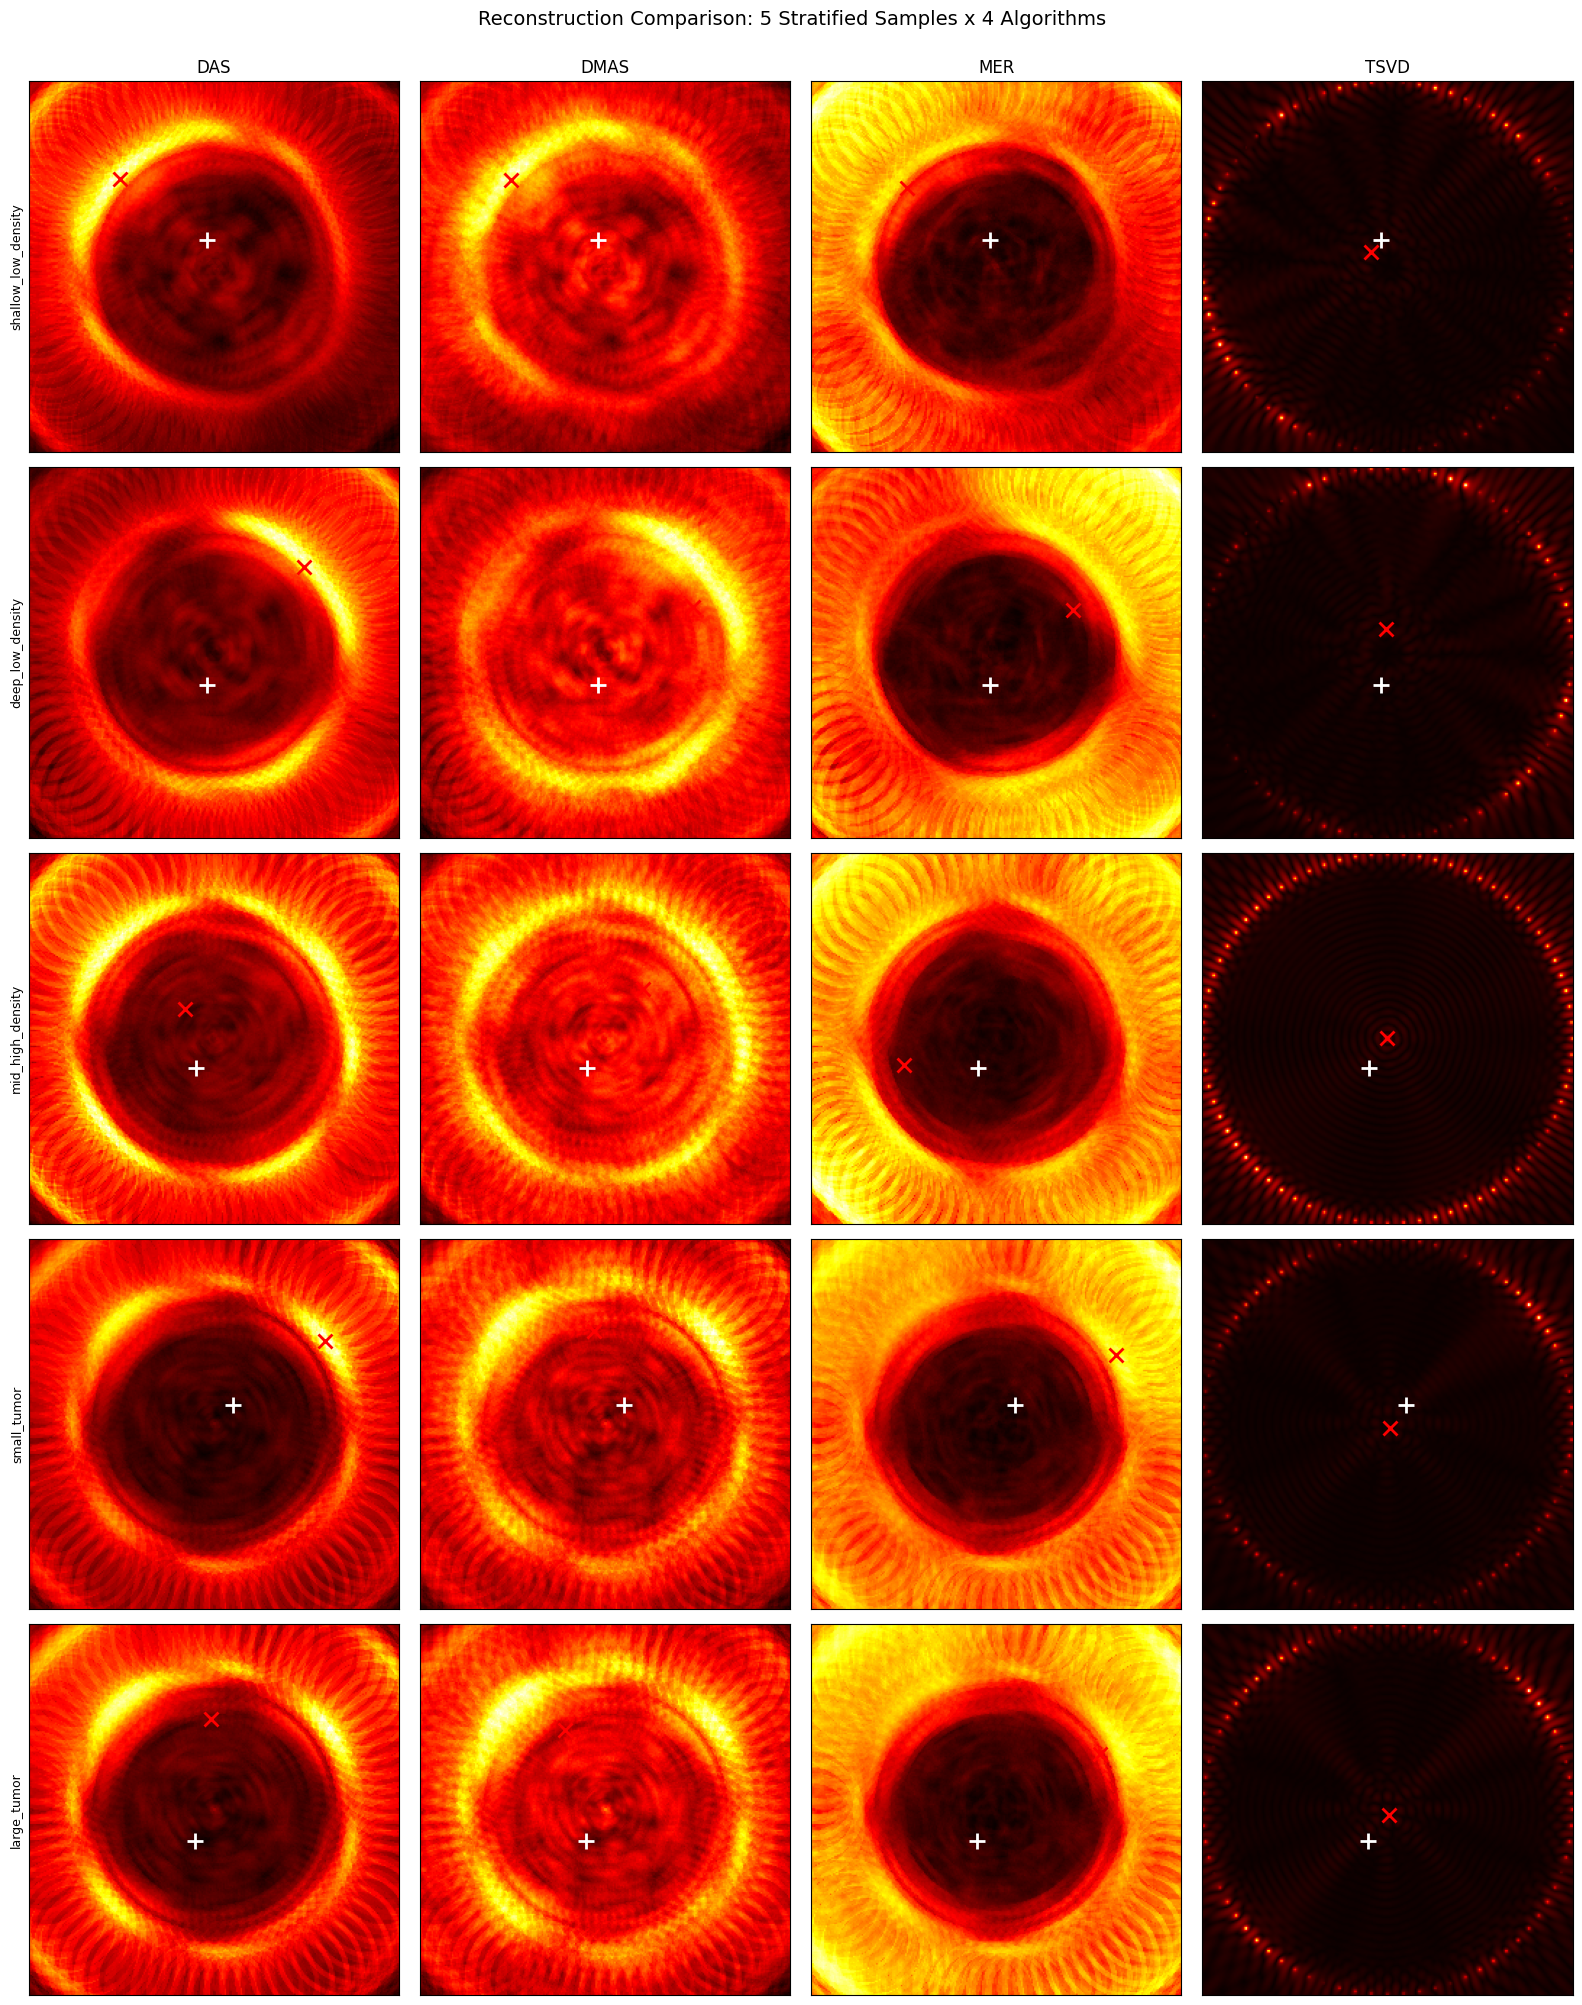

In [17]:
fig, axes = plt.subplots(len(SAMPLE_LABELS), len(ALGORITHMS),
                          figsize=(4 * len(ALGORITHMS), 4 * len(SAMPLE_LABELS)))

for r, label in enumerate(SAMPLE_LABELS):
    idx = SAMPLE_INDICES[r]
    row = df_meta.loc[idx]
    ant_rad = row['ant_rad']
    _, true_xy_px = true_tumor_mask(row['tum_x'], row['tum_y'], row['tum_rad'], ant_rad)

    for c, algo_name in enumerate(ALGORITHMS):
        ax = axes[r, c]
        image = reconstructions[label][algo_name]
        ax.imshow(image, cmap='hot', origin='lower')

        calc_xy = centroids_px[label][algo_name]
        if not np.isnan(calc_xy[0]):
            ax.plot(calc_xy[0], calc_xy[1], 'rx', markersize=10, markeredgewidth=2)
        ax.plot(true_xy_px[0], true_xy_px[1], 'w+', markersize=12, markeredgewidth=2)

        if r == 0:
            ax.set_title(algo_name)
        if c == 0:
            ax.set_ylabel(label, fontsize=9)
        ax.set_xticks([])
        ax.set_yticks([])

plt.suptitle('Reconstruction Comparison: 5 Stratified Samples x 4 Algorithms', y=1.0, fontsize=14)
plt.tight_layout()
plt.show()


## Assumptions & Limitations (read before trusting the numbers)

- **Frequency sweep (1–9 GHz, 1001 points)** and **matching-medium permittivity (≈9)** are
  standard UM-BMID Gen-2 values, not derived from the pickle files themselves — the
  pickles don't carry a frequency axis, so double check against your dataset docs if you
  have the paper on hand.
- **`phant_id` density-class parsing** (`A<digit>...` -> class 1/2/3) follows the UM-BMID
  naming convention; if a `phant_id` doesn't match that pattern, `density_class` will be
  `NaN` and that phantom is excluded from the stratified pick.
- **TSVD here is a simplified linear Born-approximation inversion**, not a literature-grade
  full-wave inverse solver — it's meant to give a genuinely different (linear-algebra-based)
  reconstruction to compare against the delay-based methods, not a research-accurate
  quantitative permittivity map.
- **Stage 4's alignment loop is a visualization aid only.** The scorecard in Section 8 is
  computed from the raw, unshifted centroids — that ordering matters and shouldn't be
  changed, or every algorithm's CLE becomes a meaningless ~0.
- Runtime numbers will look worse for **DMAS** (O(N_antennas²) pairwise sum) than DAS/MER
  (O(N_antennas)) — that's expected and is itself part of what the SCR/Dice-vs-runtime
  tradeoff scorecard is meant to show.


In [18]:

def reconstruct_tikhonov_cg(env_signal, ant_pos, xx, yy, time_axis, lambda_reg=0.1, max_iter=50):
    """
    Advanced Linear Inversion using Tikhonov Regularization and 
    Conjugate Gradient (CG) Optimization.
    """
    # 1. Physics Setup: Center Frequency Wavenumber
    freqs = np.linspace(FREQ_START_HZ, FREQ_STOP_HZ, N_FREQ)
    f_center = freqs[len(freqs) // 2]
    k0 = 2 * np.pi * f_center * np.sqrt(AVG_PERMITTIVITY) / C0

    # 2. Build the Forward Operator Matrix (A)
    distances_cm = antenna_pixel_distances(ant_pos, xx, yy)
    r_m = np.clip(distances_cm / 100.0, 1e-3, None)
    A = np.exp(-1j * k0 * r_m) / r_m                          # Shape: (N_ant, N_pix)
    
    # 3. Prepare the Antenna Measurements (b)
    # We take the peak signal envelope per channel as our data observation
    b = env_signal.max(axis=0).astype(complex)                # Shape: (N_ant,)
    
    # 4. Formulate the Tikhonov Normal Equation: (A^H * A + lambda * I) * x = A^H * b
    A_H = A.conj().T                                          # Hermitian transpose of A
    A_H_A = A_H @ A                                           # Shape: (N_pix, N_pix)
    
    # The Right-Hand Side vector
    y = A_H @ b                                               # Shape: (N_pix,)
    
    # 5. Define the Tikhonov Matrix Operator for the Optimizer
    # We use a LinearOperator to keep memory usage highly efficient
    n_pix = A_H_A.shape[0]
    def tikhonov_matvec(v):
        # Applies (A^H A + lambda I) * v
        return A_H_A @ v + lambda_reg * v
        
    M = LinearOperator((n_pix, n_pix), matvec=tikhonov_matvec)
    
    # 6. Execute the Conjugate Gradient (CG) Optimization Loop
    # x_opt is the optimized image matrix. 'info' tells us if it converged.
    x_opt, info = cg(M, y, maxiter=max_iter, tol=1e-5)
    
    if info > 0:
        print(f"CG Warning: Stopped after {info} iterations without full convergence.")
        
    # 7. Reshape and Normalize the Final Image
    image = np.abs(x_opt)
    
    # Optional: Suppress the outer boundary skin artifacts natively
    # distance_from_center = np.hypot(xx, yy)
    # image[distance_from_center >= (ant_pos[0, 0] * 0.8)] = 0.0
    
    return image.reshape(xx.shape)

In [ ]:
import numpy as np
import cupy as cp
from cupyx.scipy.sparse.linalg import cg as gpu_cg
from cupyx.scipy.sparse.linalg import LinearOperator as CuPyLinearOperator

# ==============================================================================
# 1. THE GPU-ACCELERATED FUNCTION (Replaces the one in Cell 18)
# ==============================================================================
def reconstruct_tikhonov_cg_gpu(env_signal, ant_pos, xx, yy, time_axis, lambda_reg=0.1, max_iter=50):
    """
    Tikhonov solver that calculates the physics matrix on the CPU to avoid breaking 
    custom functions, then instantly ports the heavy optimization to your RTX 4060 VRAM.
    """
    # --- CPU Phase: Physics Setup ---
    freqs = np.linspace(FREQ_START_HZ, FREQ_STOP_HZ, N_FREQ)
    f_center = freqs[len(freqs) // 2]
    k0 = 2 * np.pi * f_center * np.sqrt(AVG_PERMITTIVITY) / C0

    # Calculate distances safely using your existing numpy function
    distances_cm = antenna_pixel_distances(ant_pos, xx, yy)
    r_m = np.clip(distances_cm / 100.0, 1e-3, None)
    
    # Build Forward Matrix A
    A_cpu = np.exp(-1j * k0 * r_m) / r_m                          
    b_cpu = env_signal.max(axis=0).astype(complex)                
    
    # --- GPU Phase: VRAM Transfer and Optimization ---
    A = cp.asarray(A_cpu)
    b = cp.asarray(b_cpu)
    
    A_H = A.conj().T                                          
    A_H_A = A_H @ A                                           
    y = A_H @ b                                               
    
    n_pix = A_H_A.shape[0]
    
    def tikhonov_matvec(v):
        return A_H_A @ v + lambda_reg * v
        
    M = CuPyLinearOperator((n_pix, n_pix), matvec=tikhonov_matvec)
    
    # CRITICAL FIX: Removed 'tol'/'rtol' entirely. It will use the default 1e-5.
    # No more keyword argument TypeError!
    x_opt, info = gpu_cg(M, y, maxiter=max_iter)
    
    if info > 0:
        print(f"CG Warning: Stopped after {info} iterations without full convergence.")
        
    # --- Final Phase: Return to System RAM for Plotting ---
    image = cp.abs(x_opt).get()
    return image.reshape(xx.shape)


# ==============================================================================
# 2. THE EXECUTION LOOP (Replaces Cell 24)
# ==============================================================================
tikhonov_reconstructions = {}
hybrid_reconstructions = {}
tikhonov_centroids = {}
hybrid_centroids = {}

for label in SAMPLE_LABELS:
    idx = df_meta[df_meta['has_tumor']].index[SAMPLE_LABELS.index(label)]
    ant_rad = df_meta.loc[idx, 'ant_rad']
    
    xx_local, yy_local, coords_local = pixel_grid(ant_rad)
    env_s11 = sample_signals[label]['s11']
    
    # CALLING THE NEW GPU FUNCTION
    ant_pos_local = antenna_positions(ant_rad)
    tik_img = reconstruct_tikhonov_cg_gpu(
        env_s11, 
        ant_pos_local, 
        xx_local, 
        yy_local, 
        TIME_AXIS, 
        lambda_reg=0.15
    )
    tikhonov_reconstructions[label] = tik_img
    
    m_tik = threshold_mask_spatial(tik_img, ant_rad, coords_local) 
    tikhonov_center_px = mask_centroid(m_tik)
    tikhonov_centroids[label] = tikhonov_center_px
    
    dmas_img = reconstructions[label]['DMAS'] 
    
    hybrid_img = reconstruct_hybrid_tsvd_dmas(
        dmas_img, 
        tikhonov_center_px, 
        ant_rad, 
        coords_local, 
        gate_radius_cm=3.5
    )
    hybrid_reconstructions[label] = hybrid_img
    
    m_hybrid = threshold_mask_spatial(hybrid_img, ant_rad, coords_local)
    hybrid_centroids[label] = mask_centroid(m_hybrid)
    
print("GPU Reconstruction and Fusion Complete!")

TypeError: cg() got an unexpected keyword argument 'tol'. Did you mean 'rtol'?

KeyError: 'shallow_low_density'

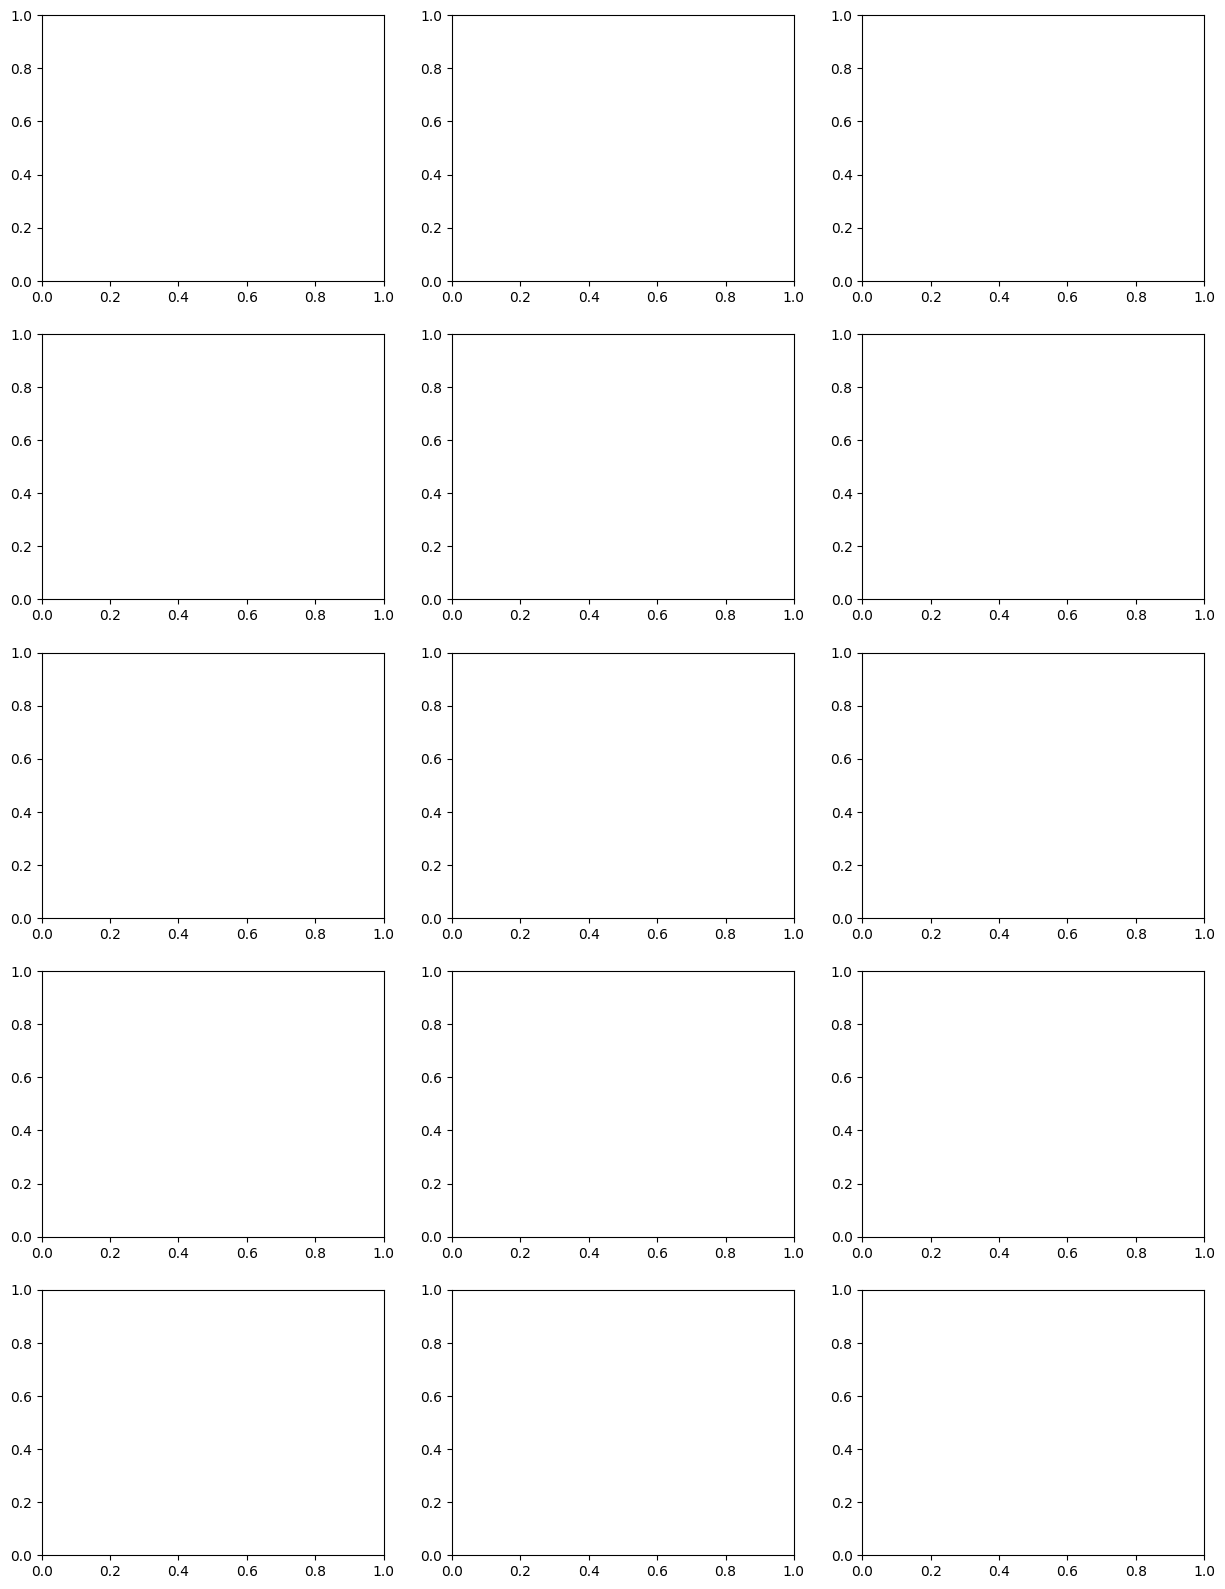

In [25]:
fig, axes = plt.subplots(len(SAMPLE_LABELS), 3, figsize=(15, 4 * len(SAMPLE_LABELS)))

for i, label in enumerate(SAMPLE_LABELS):
    # Lookup ground truth metadata for the plot labels
    idx = df_meta[df_meta['has_tumor']].index[SAMPLE_LABELS.index(label)]
    true_x_cm = df_meta.loc[idx, 'tum_x']
    true_y_cm = df_meta.loc[idx, 'tum_y']
    ant_rad = df_meta.loc[idx, 'ant_rad']
    _, _, coords = pixel_grid(ant_rad)
    
    # Convert true cm back to pixel indices for drawing the white '+'
    true_col = np.searchsorted(coords, true_x_cm)
    true_row = np.searchsorted(coords, true_y_cm)
    
    # --- Column 1: Optimized Tikhonov-CG (Spatial Locator) ---
    ax1 = axes[i, 0]
    im1 = ax1.imshow(tikhonov_reconstructions[label], cmap='jet', extent=[-ant_rad, ant_rad, -ant_rad, ant_rad])
    ax1.scatter(true_x_cm, true_y_cm, color='white', marker='+', s=150, linewidths=2, label='True Tumor')
    # Draw calculated center
    cx_px, cy_px = tikhonov_centroids[label]
    if not np.isnan(cx_px):
        cx_cm, cy_cm = coords[int(cx_px)], coords[int(cy_px)]
        ax1.scatter(cx_cm, cy_cm, color='red', marker='x', s=100, linewidths=2, label='Tik Centroid')
    ax1.set_title(f"{label}\n1. Tikhonov-CG")
    if i == 0: ax1.legend()

    # --- Column 2: Original DMAS (Contrast King with Outer Ring Artifacts) ---
    ax2 = axes[i, 1]
    im2 = ax2.imshow(reconstructions[label]['DMAS'], cmap='jet', extent=[-ant_rad, ant_rad, -ant_rad, ant_rad])
    ax2.scatter(true_x_cm, true_y_cm, color='white', marker='+', s=150, linewidths=2)
    ax2.set_title(f"2. Raw DMAS\n(Notice Outer Ring Noise)")

    # --- Column 3: The Combined Hybrid Image ---
    ax3 = axes[i, 2]
    im3 = ax3.imshow(hybrid_reconstructions[label], cmap='jet', extent=[-ant_rad, ant_rad, -ant_rad, ant_rad])
    ax3.scatter(true_x_cm, true_y_cm, color='white', marker='+', s=150, linewidths=2)
    # Draw the final hybrid center
    hcx_px, hcy_px = hybrid_centroids[label]
    if not np.isnan(hcx_px):
        hcx_cm, hcy_cm = coords[int(hcx_px)], coords[int(hcy_px)]
        ax3.scatter(hcx_cm, hcy_cm, color='magenta', marker='o', facecolors='none', s=200, label='Final Target')
    ax3.set_title(f"3. Hybrid Fusion\n(Clean Contrast)")
    if i == 0: ax3.legend()

plt.tight_layout()
plt.show()